<a href="https://colab.research.google.com/github/rajesh0305/Image-Processing-And-Computer-Vision-/blob/main/IPCV_LAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMAGE ENHANCEMENT USING HISTOGRAM EQUALIZATION
Using user-provided image: /content/drive/MyDrive/5flowersdata-20251210T063634Z-3-001/5flowersdata/flowers/train/Lilly/00048a5c76.jpg

Method 1: Manual Implementation
----------------------------------------
Image Dimensions: 183x275
Total Pixels: 50325


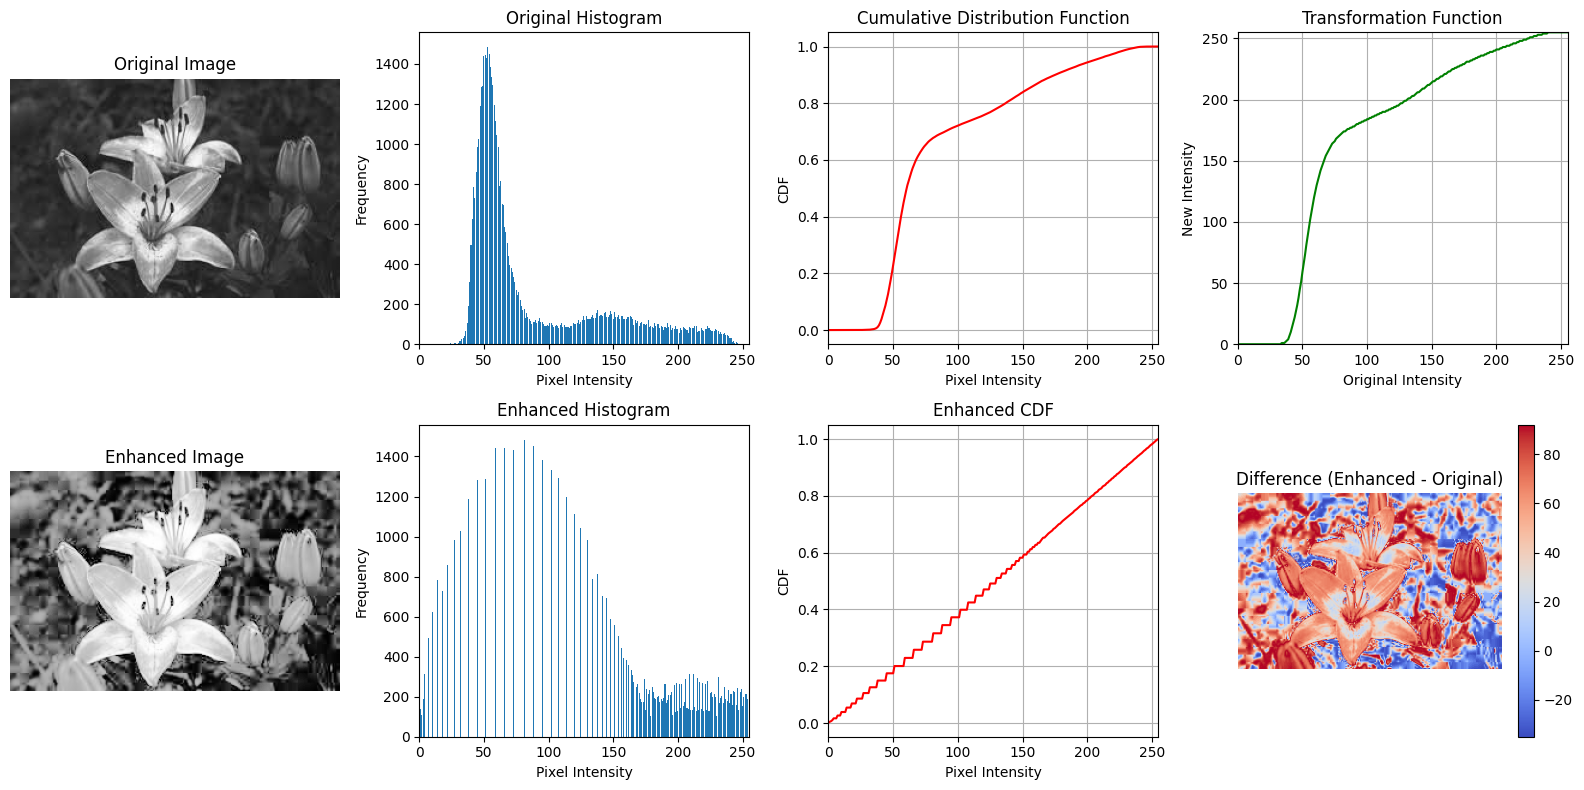


Original Image Statistics:
  Min intensity: 9
  Max intensity: 250
  Mean intensity: 87.03
  Standard deviation: 52.56

Enhanced Image Statistics:
  Min intensity: 0
  Max intensity: 255
  Mean intensity: 129.31
  Standard deviation: 72.55

Enhanced image saved as 'enhanced_image.jpg'


Method 2: Using OpenCV Built-in Function
----------------------------------------


/tmp/ipython-input-4220055420.py:144: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(enhanced_img.flatten(), 256, [0, 256])


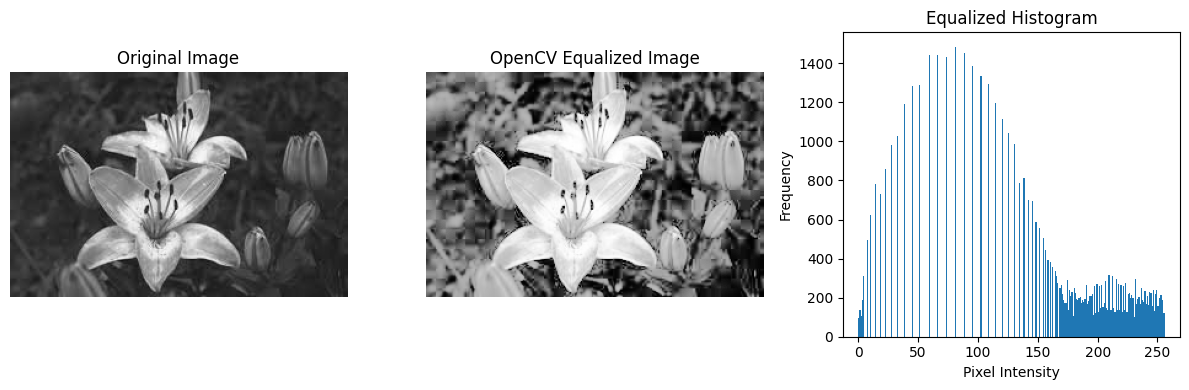


Experiment completed successfully!


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def histogram_equalization(image_path):
    """
    Perform histogram equalization on a grayscale image
    """

    # Step 1: Read the input grayscale image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: Could not read image from {image_path}")
        return None

    # Get image dimensions
    height, width = img.shape
    total_pixels = height * width

    print(f"Image Dimensions: {height}x{width}")
    print(f"Total Pixels: {total_pixels}")

    # Step 2: Compute the histogram of the image
    hist = np.zeros(256, dtype=int)

    # Efficient way using numpy
    hist, _ = np.histogram(img.flatten(), 256, [0, 256])

    # Step 3: Normalize the histogram (probability distribution)
    hist_normalized = hist / total_pixels

    # Step 4: Compute the cumulative distribution function (CDF)
    cdf = np.cumsum(hist_normalized)

    # Step 5: Map old gray levels to new gray levels using CDF
    # s = (L-1) * CDF where L = 256 (0-255)
    L = 256
    new_values = np.zeros(256, dtype=int)

    for i in range(256):
        new_values[i] = int(round((L - 1) * cdf[i]))

    # Step 6: Create enhanced image with new values using vectorization
    enhanced_img = new_values[img]

    return img, enhanced_img, hist, cdf, new_values

def display_results(original, enhanced, hist, cdf, new_values):
    """
    Display original and enhanced images with histograms
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    # Original Image
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    # Original Histogram
    axes[0, 1].bar(range(256), hist)
    axes[0, 1].set_title('Original Histogram')
    axes[0, 1].set_xlabel('Pixel Intensity')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_xlim([0, 255])

    # Original CDF
    axes[0, 2].plot(range(256), cdf, 'r-')
    axes[0, 2].set_title('Cumulative Distribution Function')
    axes[0, 2].set_xlabel('Pixel Intensity')
    axes[0, 2].set_ylabel('CDF')
    axes[0, 2].set_xlim([0, 255])
    axes[0, 2].grid(True)

    # Transformation Function
    axes[0, 3].plot(range(256), new_values, 'g-')
    axes[0, 3].set_title('Transformation Function')
    axes[0, 3].set_xlabel('Original Intensity')
    axes[0, 3].set_ylabel('New Intensity')
    axes[0, 3].set_xlim([0, 255])
    axes[0, 3].set_ylim([0, 255])
    axes[0, 3].grid(True)

    # Enhanced Image
    axes[1, 0].imshow(enhanced, cmap='gray')
    axes[1, 0].set_title('Enhanced Image')
    axes[1, 0].axis('off')

    # Enhanced Histogram
    enhanced_hist, _ = np.histogram(enhanced.flatten(), 256, [0, 256])
    axes[1, 1].bar(range(256), enhanced_hist)
    axes[1, 1].set_title('Enhanced Histogram')
    axes[1, 1].set_xlabel('Pixel Intensity')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim([0, 255])

    # Enhanced CDF
    enhanced_cdf = np.cumsum(enhanced_hist) / np.sum(enhanced_hist)
    axes[1, 2].plot(range(256), enhanced_cdf, 'r-')
    axes[1, 2].set_title('Enhanced CDF')
    axes[1, 2].set_xlabel('Pixel Intensity')
    axes[1, 2].set_ylabel('CDF')
    axes[1, 2].set_xlim([0, 255])
    axes[1, 2].grid(True)

    # Difference Image
    diff = enhanced.astype(int) - original.astype(int)
    im_diff = axes[1, 3].imshow(diff, cmap='coolwarm')
    axes[1, 3].set_title('Difference (Enhanced - Original)')
    axes[1, 3].axis('off')
    plt.colorbar(im_diff, ax=axes[1, 3])

    plt.tight_layout()
    plt.show()

def using_opencv_function(image_path):
    """
    Demonstrate using OpenCV's built-in equalizeHist function
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: Could not read image from {image_path}")
        return None

    # Using OpenCV's built-in function
    enhanced_img = cv2.equalizeHist(img)

    # Display results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(enhanced_img, cmap='gray')
    plt.title('OpenCV Equalized Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.hist(enhanced_img.flatten(), 256, [0, 256])
    plt.title('Equalized Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    return enhanced_img

def create_sample_image():
    """
    Create a sample low-contrast image for testing
    """
    # Create a simple low-contrast gradient image
    img = np.zeros((256, 256), dtype=np.uint8)

    # Create horizontal gradient (low contrast)
    for i in range(256):
        img[i, :] = 100 + int(55 * np.sin(i * np.pi / 128))

    # Add some noise
    noise = np.random.normal(0, 10, (256, 256)).astype(np.uint8)
    img = cv2.add(img, noise)

    # Clip values to 0-255
    img = np.clip(img, 0, 255).astype(np.uint8)

    # Save the image
    cv2.imwrite('sample_low_contrast.jpg', img)
    print("Sample image created: 'sample_low_contrast.jpg'")

    return 'sample_low_contrast.jpg'

def check_image_exists(image_path):
    """
    Check if image file exists
    """
    if os.path.exists(image_path):
        return True
    else:
        print(f"Warning: Image file '{image_path}' not found.")
        return False

def main():
    """
    Main function to run histogram equalization
    """
    print("=" * 60)
    print("IMAGE ENHANCEMENT USING HISTOGRAM EQUALIZATION")
    print("=" * 60)

    image_path = None # Initialize image_path
    user_provided_path = '/content/drive/MyDrive/5flowersdata-20251210T063634Z-3-001/5flowersdata/flowers/train/Lilly/00048a5c76.jpg'

    # Prioritize user-provided path if it exists
    if check_image_exists(user_provided_path):
        image_path = user_provided_path
        print(f"Using user-provided image: {image_path}")
    else:
        # Check for command line arguments, but filter out '-f' from IPython/Jupyter
        import sys
        if len(sys.argv) > 1 and sys.argv[1] != '-f':
            image_path = sys.argv[1]
            print(f"Using image from command line: {image_path}")
        else:
            print("No valid command line image path provided. Checking default paths...")

        if image_path is None: # If not set by command line, try default paths
            possible_paths = ['input_image.jpg', 'sample_low_contrast.jpg']

            for path in possible_paths:
                if os.path.exists(path):
                    image_path = path
                    print(f"Using image: {image_path}")
                    break

        if image_path is None: # If still no image path, create a sample image
            print("No image found in default paths. Creating a sample image...")
            image_path = create_sample_image()

    print("\nMethod 1: Manual Implementation")
    print("-" * 40)

    # Manual implementation
    result = histogram_equalization(image_path)

    if result is not None:
        original, enhanced, hist, cdf, new_values = result

        # Display results
        display_results(original, enhanced, hist, cdf, new_values)

        # Calculate and print statistics
        print(f"\nOriginal Image Statistics:")
        print(f"  Min intensity: {np.min(original)}")
        print(f"  Max intensity: {np.max(original)}")
        print(f"  Mean intensity: {np.mean(original):.2f}")
        print(f"  Standard deviation: {np.std(original):.2f}")

        print(f"\nEnhanced Image Statistics:")
        print(f"  Min intensity: {np.min(enhanced)}")
        print(f"  Max intensity: {np.max(enhanced)}")
        print(f"  Mean intensity: {np.mean(enhanced):.2f}")
        print(f"  Standard deviation: {np.std(enhanced):.2f}")

        # Save the enhanced image
        cv2.imwrite('enhanced_image.jpg', enhanced)
        print(f"\nEnhanced image saved as 'enhanced_image.jpg'")
    else:
        print("Failed to process image.")
        return

    print("\n" + "=" * 60)
    print("\nMethod 2: Using OpenCV Built-in Function")
    print("-" * 40)

    # Using OpenCV built-in function
    cv2_result = using_opencv_function(image_path)

    if cv2_result is not None:
        print("\n" + "=" * 60)
        print("Experiment completed successfully!")
        print("=" * 60)
    else:
        print("Failed to process image with OpenCV.")

if __name__ == "__main__":
    # Run the main function
    main()